# Classificação de Galáxias com Random Forest e diferentes PRNGs

Este notebook foi organizado em funções documentadas (docstrings no padrão Sphinx/NumPy), mantendo a lógica original: carregar o dataset, dividir em treino/validação/teste, e treinar um `RandomForestClassifier` utilizando três geradores de números pseudoaleatórios diferentes (`PCG64`, `SFC64` e `MT19937`), avaliando o desempenho de cada um.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy.random import PCG64, SFC64, MT19937

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


## 1. Carregamento dos dados

In [2]:
def load_dataset(path: str) -> pd.DataFrame:
    """
    Carrega o conjunto de dados de galáxias a partir de um arquivo CSV.

    Parameters
    ----------
    path : str
        Caminho do arquivo CSV contendo o conjunto de dados.

    Returns
    -------
    pandas.DataFrame or None
        DataFrame contendo todas as amostras, ou ``None`` caso o
        arquivo não seja encontrado.
    """

    try:
        return pd.read_csv(path)
    except FileNotFoundError:
        print("Arquivo não encontrado...")
        return None


In [3]:
def preview_dataset(df: pd.DataFrame, n_rows: int = 5) -> int:
    """
    Exibe as primeiras linhas do DataFrame e o número total de amostras.

    Parameters
    ----------
    df : pandas.DataFrame
        Conjunto de dados a ser inspecionado.
    n_rows : int, optional
        Número de linhas a serem exibidas (padrão: 5).

    Returns
    -------
    int
        Número total de linhas (amostras) do DataFrame.
    """

    print(df.head(n_rows))
    total_linhas = len(df)
    print(total_linhas)
    return total_linhas


In [4]:
df = load_dataset("galaxies.csv")
total_linhas = preview_dataset(df, n_rows=5)


   sequentialid  type        gg       m20        cc        aa  sersic_n_gim2d  \
0       87785.0   2.0 -0.178659  0.408056  0.195886 -0.090374       -0.476385   
1       87789.0   2.0  0.542650 -0.742287  0.370185 -0.287801        0.546606   
2       87792.0   2.0  0.984253 -1.223489  1.186458  0.262630        1.562971   
3       87794.0   1.0  1.775592 -1.264211  1.249540 -0.148394        2.043435   
4       87795.0   2.0  0.319965 -0.831671  0.811909  0.518061        0.831674   

   ell_gim2d   r_gim2d  
0   1.510386  0.014649  
1   1.602553 -0.936228  
2   0.707001 -0.536047  
3   0.158608 -0.770333  
4   0.879145 -0.150464  
34874


## 2. Separação entre atributos (features) e rótulo (target)

In [5]:
def split_features_target(
    df: pd.DataFrame,
    target_col: str = "type",
    max_unique_classes: int = 20,
):
    """
    Separa o DataFrame em atributos (features) e rótulo (target).

    Como proteção contra erros de configuração (por exemplo, apontar
    target_col para uma coluna contínua por engano, ou usar uma
    variável de rótulo desatualizada por execução de células fora de
    ordem no Jupyter), esta função verifica se o rótulo selecionado se
    parece com uma variável categórica, alertando caso contrário.

    Parameters
    ----------
    df : pandas.DataFrame
        Conjunto de dados completo.
    target_col : str, optional
        Nome da coluna que representa o rótulo/classe (padrão: "type").
    max_unique_classes : int, optional
        Número máximo de valores únicos esperado para uma coluna
        categórica válida (padrão: 20). Se target_col tiver mais
        valores únicos que isso, um ValueError é levantado, pois
        provavelmente não se trata de uma coluna de classes.

    Returns
    -------
    tuple of (pandas.DataFrame, pandas.Series)
        Uma tupla (X, y) em que X contém as features e y
        contém os rótulos.

    Raises
    ------
    ValueError
        Se target_col não existir em df, ou se ela tiver mais
        valores únicos que max_unique_classes (indício de que não
        é uma coluna categórica válida).
    """

    if target_col not in df.columns:
        raise ValueError(
            f"A coluna '{target_col}' não existe no DataFrame. "
            f"Colunas disponíveis: {list(df.columns)}."
        )

    n_unicos = df[target_col].nunique(dropna=False)
    if n_unicos > max_unique_classes:
        raise ValueError(
            f"A coluna '{target_col}' tem {n_unicos} valores únicos, "
            f"mais do que o esperado para um rótulo categórico "
            f"(máximo: {max_unique_classes}). Isso sugere que "
            f"'{target_col}' não é a coluna de classes correta — "
            "verifique se as células foram executadas na ordem certa "
            "e se nenhuma variável está desatualizada (dica: reinicie "
            "o kernel e execute o notebook do início)."
        )

    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y


In [6]:
dataset_rf, types = split_features_target(df, target_col="type")


## 3. Divisão dos dados em treino, validação e teste

In [7]:
def check_class_distribution(y: pd.Series, min_per_class: int = 2) -> pd.Series:
    """
    Verifica a distribuição das classes do rótulo e garante que cada
    classe possui amostras suficientes para uma divisão estratificada
    (train_test_split(..., stratify=...)).

    Parameters
    ----------
    y : pandas.Series
        Rótulos (classes) do conjunto de dados.
    min_per_class : int, optional
        Número mínimo de amostras exigido por classe (padrão: 2).

    Returns
    -------
    pandas.Series
        Contagem de amostras por classe (ordenada de forma crescente),
        útil para inspeção manual.

    Raises
    ------
    ValueError
        Se ``y`` contiver valores ausentes (``NaN``), ou se alguma
        classe tiver menos amostras que ``min_per_class``.
    """

    n_ausentes = y.isna().sum()
    if n_ausentes > 0:
        raise ValueError(
            f"A coluna de rótulo possui {n_ausentes} valor(es) ausente(s) "
            "(NaN). Isso impede a divisão estratificada, pois cada linha "
            "com NaN é tratada como uma classe própria com apenas 1 membro. "
            "Remova ou trate essas linhas (ex.: `df = df.dropna(subset=[\'type\'])`) "
            "antes de continuar."
        )

    contagem = y.value_counts(dropna=False).sort_values()

    classes_insuficientes = contagem[contagem < min_per_class]
    if not classes_insuficientes.empty:
        raise ValueError(
            "As seguintes classes têm menos de "
            f"{min_per_class} amostras e impedem a divisão estratificada: "
            f"{classes_insuficientes.to_dict()}. "
            "Considere remover essas amostras, agrupá-las a outra classe, "
            "ou coletar mais dados para essas classes antes de prosseguir. "
            "Use `find_rare_class_rows(df, y, min_per_class=2)` para inspecionar "
            "as linhas correspondentes e investigar a causa (ex.: erro de "
            "parsing/alinhamento no CSV)."
        )

    return contagem


In [8]:
def find_rare_class_rows(
    df: pd.DataFrame,
    y: pd.Series,
    target_col: str = "type",
    min_per_class: int = 2,
) -> pd.DataFrame:
    """
    Localiza, no DataFrame original, as linhas cujo rótulo pertence a
    uma classe com menos amostras do que min_per_class.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame original (antes da separação entre features e rótulo),
        preservando todas as colunas para facilitar a inspeção.
    y : pandas.Series
        Rótulos (classes) correspondentes às linhas de df.
    target_col : str, optional
        Nome da coluna de rótulo em df (padrão: "type").
    min_per_class : int, optional
        Número mínimo de amostras exigido por classe (padrão: 2).

    Returns
    -------
    pandas.DataFrame
        Subconjunto de df contendo apenas as linhas cujas classes
        têm menos de min_per_class amostras.
    """

    contagem = y.value_counts(dropna=False)
    classes_raras = contagem[contagem < min_per_class].index

    return df[df[target_col].isin(classes_raras)]


In [9]:
# Caso `check_class_distribution` acuse alguma classe rara, use a célula
# abaixo para inspecionar as linhas correspondentes no DataFrame original.
# Exemplo:
# linhas_suspeitas = find_rare_class_rows(df, types, target_col="type", min_per_class=2)
# linhas_suspeitas


In [10]:
distribuicao_classes = check_class_distribution(types, min_per_class=2)
distribuicao_classes


,count
type,
1.0,3193
3.0,4058
2.0,27623


In [11]:
def split_train_val_test(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.15,
    val_size: float = 0.1765,
    random_state: int = 57,
):
    """
    Divide os dados em conjuntos de treino, validação e teste, mantendo
    a proporção das classes (estratificação).

    A divisão é feita em duas etpsd: primeiro separa-se o conjunto de
    teste do restante dos dados; em seguida, o conjunto restante é
    dividido em treino e validação.

    Parameters
    ----------
    X : pandas.DataFrame
        Atributos (features) do conjunto de dados.
    y : pandas.Series
        Rótulos (classes) correspondentes a ``X``.
    test_size : float, optional
        Proporção dos dados destinada ao conjunto de teste (padrão: 0.15).
    val_size : float, optional
        Proporção do conjunto remanescente (após separar o teste)
        destinada à validação (padrão: 0.1765, o que resulta em
        aproximadamente 15% do total).
    random_state : int, optional
        Semente utilizada para reprodutibilidade da divisão (padrão: 57).

    Returns
    -------
    tuple
        Uma tupla (X_train, X_val, X_test, y_train, y_val, y_test).

    Raises
    ------
    ValueError
        Se alguma classe de y tiver menos de 2 amostras, o que
        impede a divisão estratificada (ver :func:check_class_distribution).
    """

    check_class_distribution(y, min_per_class=2)

    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=val_size,
        random_state=random_state,
        stratify=y_temp,
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


In [12]:
def print_split_summary(X_train, X_val, X_test, total: int) -> None:
    """
    Exibe um resumo (contagem e percentual) da divisão dos dados.

    Parameters
    ----------
    X_train : pandas.DataFrame
        Conjunto de treino.
    X_val : pandas.DataFrame
        Conjunto de validação.
    X_test : pandas.DataFrame
        Conjunto de teste.
    total : int
        Número total de amos do conjunto de dados original.

    Returns
    -------
    None
    """

    print("Treino:", len(X_train))
    print("Validação:", len(X_val))
    print("Teste:", len(X_test))

    print(f"Treino: {100 * len(X_train) / total:.2f}%")
    print(f"Validação: {100 * len(X_val) / total:.2f}%")
    print(f"Teste: {100 * len(X_test) / total:.2f}%")


In [13]:
X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    dataset_rf,
    types,
    test_size=0.15,
    val_size=0.1765,
    random_state=57,
)

print_split_summary(X_train, X_val, X_test, total=len(dataset_rf))


Treino: 24410
Validação: 5232
Teste: 5232
Treino: 69.99%
Validação: 15.00%
Teste: 15.00%


## 4. Geradores de números pseudoaleatórios (PRNGs)

In [14]:
def create_random_generators(seed: int = 57):
    """
    Cria três geradores de números pseudoaleatórios (RandomState)
    baseados em diferentes algoritmos de bit generator do NumPy.

    Parameters
    ----------
    seed : int, optional
        Semente utilizada para inicializar os três geradores (padrão: 57).

    Returns
    -------
    tuple of numpy.random.RandomState
        Uma tupla ``(gen1, gen2, gen3)`` contendo, respectivamente, os
        geradores baseados em ``PCG64``, ``SFC64`` e ``MT19937``.
    """

    generator1 = PCG64(seed=seed)
    generator2 = SFC64(seed=seed)
    generator3 = MT19937(seed=seed)

    gen1 = np.random.RandomState(generator1)
    gen2 = np.random.RandomState(generator2)
    gen3 = np.random.RandomState(generator3)

    return gen1, gen2, gen3


In [15]:
gen1, gen2, gen3 = create_random_generators(seed=57)


## 5. Funções de treinamento e avaliação do modelo

In [16]:
def build_random_forest(random_state) -> RandomForestClassifier:
    """
    Constrói um RandomForestClassifier com os hiperparâmetros padrão
    utilizados neste experimento.

    Parameters
    ----------
    random_state : int, numpy.random.RandomState or numpy.random.Generator
        Estado/gerador aleatório utilizado pelo classificador para
        garantir reprodutibilidade.

    Returns
    -------
    sklearn.ensemble.RandomForestClassifier
        Instância (ainda não treinada) do classificador Random Forest.
    """

    return RandomForestClassifier(
        n_estimators=101,
        criterion="gini",
        max_features="sqrt",
        max_depth=25,
        random_state=random_state,
        class_weight="balanced",
    )


In [17]:
def cross_validate_model(
    model: RandomForestClassifier,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    cv: int = 7,
    scoring: str = "accuracy",
) -> np.ndarray:
    """
    Executa validação cruzada estratificada sobre o conjunto de treino.

    Parameters
    ----------
    model : sklearn.ensemble.RandomForestClassifier
        Modelo a ser validado.
    X_train : pandas.DataFrame
        Atributos do conjunto de treino.
    y_train : pandas.Series
        Rótulos do conjunto de treino.
    cv : int, optional
        Número de folds utilizados na validação cruzada (padrão: 7).
    scoring : str, optional
        Métrica utilizada para avaliar cada fold (padrão: "accuracy").

    Returns
    -------
    numpy.ndarray
        Vetor com a pontuação obtida em cada fold da validação cruzada.
    """

    return cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
    )


In [18]:
def report_cv_scores(
    cv_scores: np.ndarray,
    generator_name: str,
    scoring: str = "accuracy",
) -> dict:
    """
    Exibe e resume os resultados da validação cruzada (média e
    desvio-padrão), evitando que a validação cruzada seja calculada
    sem que seus resultados sejam efetivamente utilizados.

    Parameters
    ----------
    cv_scores : numpy.ndarray
        Vetor com a pontuação obtida em cada fold da validação cruzada.
    generator_name : str
        Nome do gerador de números pseudoaleatórios, usado apenas para
        identificação na impressão.
    scoring : str, optional
        Nome da métrica utilizada, usado apenas para exibição
        (padrão: "accuracy").

    Returns
    -------
    dict
        Dicionári com a média ("mean"), o desvio-padrão
        ("std") e os valores brutos ("scores`) da validação
        cruzada.
    """

    mean_score = cv_scores.mean()
    std_score = cv_scores.std()

    print(
        f"Validação cruzada ({generator_name}) - {scoring}: "
        f"{mean_score:.4f} ± {std_score:.4f}"
    )

    return {"mean": mean_score, "std": std_score, "scores": cv_scores}


In [19]:
def train_model(
    model: RandomForestClassifier,
    X_train: pd.DataFrame,
    y_train: pd.Series,
) -> RandomForestClassifier:
    """
    Treina (ajusta) o modelo com o conjunto de treino.

    Parameters
    ----------
    model : sklearn.ensemble.RandomForestClassifier
        Modelo a ser treinado.
    X_train : pandas.DataFrame
        Atributos do conjunto de treino.
    y_train : pandas.Series
        Rótulos do conjunto de treino.

    Returns
    -------
    sklearn.ensemble.RandomForestClassifier
        O próprio modelo, já treinado.
    """

    model.fit(X_train, y_train)
    return model


In [20]:
def evaluate_model(
    model: RandomForestClassifier,
    X: pd.DataFrame,
    y: pd.Series,
    dataset_name: str = "Validação",
):
    """
    Avalia o modelo em um conjunto de dados, imprimindo a acurácia e o
    relatório de classificação.

    Parameters
    ----------
    model : sklearn.ensemble.RandomForestClassifier
        Modelo treinado a ser avaliado.
    X : pandas.DataFrame
        Atributos do conjunto de dados a ser avaliado.
    y : pandas.Series
        Rótulos verdadeiros correspondentes a X.
    dataset_name : str, optional
        Nome do conjunto de dados, usado apenas para exibição
        (padrão: "Validação").

    Returns
    -------
    tuple of (numpy.ndarray, float, dict)
        Uma tupla ``(y_pred, accuracy, report_dict)`` em que
        ``y_pred`` são as predições do modelo, ``accuracy`` é a
        acurácia obtida e ``report_dict`` é o relatório de
        classificação em formato de dicionário (útil para combinar
        resultados posteriormente).
    """

    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    report_dict = classification_report(y, y_pred, output_dict=True)

    print(f"Acurácia ({dataset_name}): {acc:.4f}")
    print(classification_report(y, y_pred))

    return y_pred, acc, report_dict


In [21]:
def plot_confusion(
    y_true: pd.Series,
    y_pred: np.ndarray,
    labels,
    title: str,
) -> None:
    """
    Calcula e exibe a matriz de confusão para um conjunto de predições.

    Parameters
    ----------
    y_true : pandas.Series
        Rótulos verdadeiros.
    y_pred : numpy.ndarray
        Rótulos preditos pelo modelo.
    labels : array-like
        Lista/array com os rótulos das classes (ex.: model.classes_).
    title : str
        Título exibido no gráfico da matriz de confusão.

    Returns
    -------
    None
    """

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
    )

    disp.plot()
    plt.title(title)
    plt.show()


In [22]:
def run_experiment(
    generator_name: str,
    random_state,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    cv: int = 7,
    plot_val_confusion: bool = False,
    plot_test_confusion: bool = False,
) -> dict:
    """
    Executa o experimento completo (validação cruzada, treino e
    avaliação em validação e teste) de um RandomForestClassifier
    para um gerador de números pseudoaleatórios específico.

    A avaliação é feita de forma simétrica entre os conjuntos de
    validação e teste, independentemente do gerador utilizado.

    Parameters
    ----------
    generator_name : str
        Nome do gerador de números pseudoaleatórios utilizado (apenas
        para fins de identificação/impressão).
    random_state : numpy.random.RandomState
        Gerador de números pseudoaleatórios utilizado pelo modelo.
    X_train, y_train : pandas.DataFrame, pandas.Series
        Conjunto de treino (atributos e rótulos).
    X_val, y_val : pandas.DataFrame, pandas.Series
        Conjunto de validação (atributos e rótulos).
    X_test, y_test : pandas.DataFrame, pandas.Series
        Conjunto de teste (atributos e rótulos).
    cv : int, optional
        Número de folds utilizados na validação cruzada (padrão: 7).
    plot_val_confusion : bool, optional
        Se True, plota a matriz de confusão do conjunto de
        validação (padrão: False).
    plot_test_confusion : bool, optional
        Se True, plota a matriz de confusão do conjunto de teste
        (padrão: False).

    Returns
    -------
    dict
        Dicionário com todos os resultados do experimento: modelo
        treinado ("model"), estatísticas da validação cruzada
        ("cv_scores"), predições, acurácias e relatórios de
        classificação de validação e teste ("val_*" e "test_*").
    """

    print(f"\n===== Gerador: {generator_name} =====")

    model = build_random_forest(random_state)

    cv_scores_raw = cross_validate_model(model, X_train, y_train, cv=cv)
    cv_scores = report_cv_scores(cv_scores_raw, generator_name)

    model = train_model(model, X_train, y_train)

    y_val_pred, val_acc, val_report = evaluate_model(
        model, X_val, y_val, dataset_name="Validação"
    )
    if plot_val_confusion:
        plot_confusion(
            y_val,
            y_val_pred,
            labels=model.classes_,
            title=f"Matriz de Confusão - Validação ({generator_name})",
        )

    y_test_pred, test_acc, test_report = evaluate_model(
        model, X_test, y_test, dataset_name="Teste"
    )
    if plot_test_confusion:
        plot_confusion(
            y_test,
            y_test_pred,
            labels=model.classes_,
            title=f"Matriz de Confusão - Teste ({generator_name})",
        )

    return {
        "generator_name": generator_name,
        "model": model,
        "cv_scores": cv_scores,
        "y_val_pred": y_val_pred,
        "val_accuracy": val_acc,
        "val_report": val_report,
        "y_test_pred": y_test_pred,
        "test_accuracy": test_acc,
        "test_report": test_report,
    }


## 6. Combinação dos resultados para análise posterior

In [23]:
def combine_classification_results(results: dict) -> pd.DataFrame:
    """
    Combina os resultados de múltiplos experimentos, um por gerador
    em uma única tabela.

    Para cada gerador, são reunidas a média e o desvio-padrão da
    validação cruzada, a acurácia em validação e teste, e as métricas
    de precisão, revocação (recall) e f1-score por classe (obtidas do
    conjunto de teste).

    Parameters
    ----------
    results : dict
        Dicionário no formato {nome_do_gerador: resultado}, em que
        resultado é o dicionário retornado por :func:run_experiment.

    Returns
    -------
    pandas.DataFrame
        Tabela consolidada com uma linha por gerador e colunas com as
        principais métricas de desempenho (validação cruzada,
        acurácia de validação/teste e métricas por classe no teste).
    """

    linhas = []

    for generator_name, resultado in results.items():
        linha = {
            "gerador": generator_name,
            "cv_accuracy_mean": resultado["cv_scores"]["mean"],
            "cv_accuracy_std": resultado["cv_scores"]["std"],
            "val_accuracy": resultado["val_accuracy"],
            "test_accuracy": resultado["test_accuracy"],
        }

        # Adiciona métricas por classe (precision/recall/f1) do conjunto de teste
        for classe, metricas in resultado["test_report"].items():
            if classe in ("accuracy", "macro avg", "weighted avg"):
                continue
            for nome_metrica, valor in metricas.items():
                if nome_metrica == "support":
                    continue
                linha[f"classe_{classe}_{nome_metrica}"] = valor

        linhas.append(linha)

    return pd.DataFrame(linhas).set_index("gerador")


## 7. Execução dos experimentos com cada gerador (PCG64, SFC64, MT19937)


===== Gerador: PCG64 =====
Validação cruzada (PCG64) - accuracy: 0.9322 ± 0.0045
Acurácia (Validação): 0.9396
              precision    recall  f1-score   support

         1.0       0.85      0.78      0.82       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.86      0.88       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.88      5232
weighted avg       0.94      0.94      0.94      5232



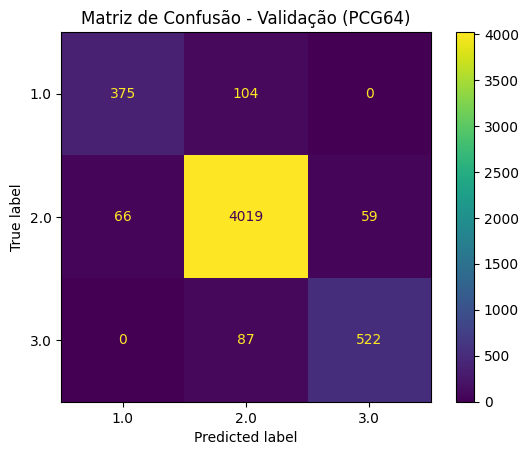

Acurácia (Teste): 0.9396
              precision    recall  f1-score   support

         1.0       0.85      0.81      0.83       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.83      0.87       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.89      5232
weighted avg       0.94      0.94      0.94      5232



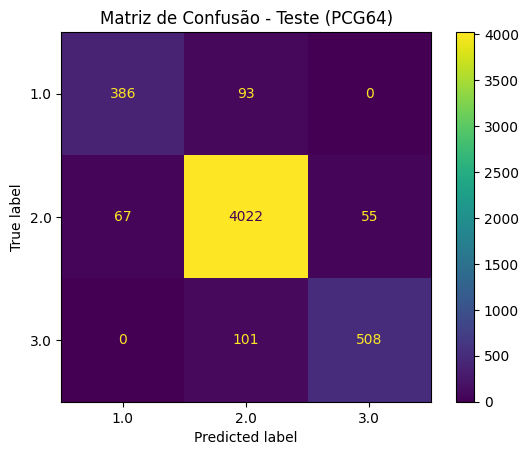

In [24]:
resultados = {}

resultados["PCG64"] = run_experiment(
    generator_name="PCG64",
    random_state=gen1,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    cv=7,
    plot_val_confusion=True,
    plot_test_confusion=True,
)



===== Gerador: SFC64 =====
Validação cruzada (SFC64) - accuracy: 0.9335 ± 0.0036
Acurácia (Validação): 0.9386
              precision    recall  f1-score   support

         1.0       0.84      0.78      0.81       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.86      0.88       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.88      5232
weighted avg       0.94      0.94      0.94      5232



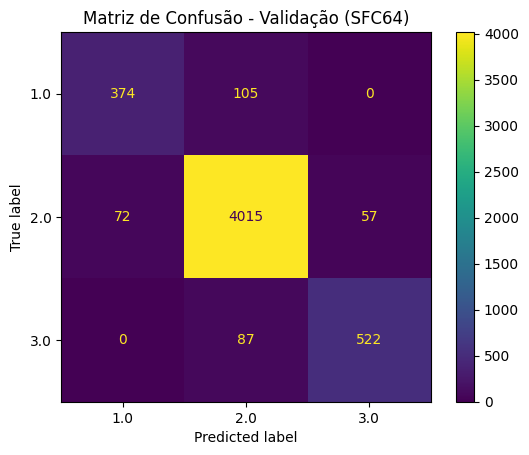

Acurácia (Teste): 0.9390
              precision    recall  f1-score   support

         1.0       0.85      0.81      0.83       479
         2.0       0.96      0.97      0.96      4144
         3.0       0.89      0.84      0.87       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.89      5232
weighted avg       0.94      0.94      0.94      5232



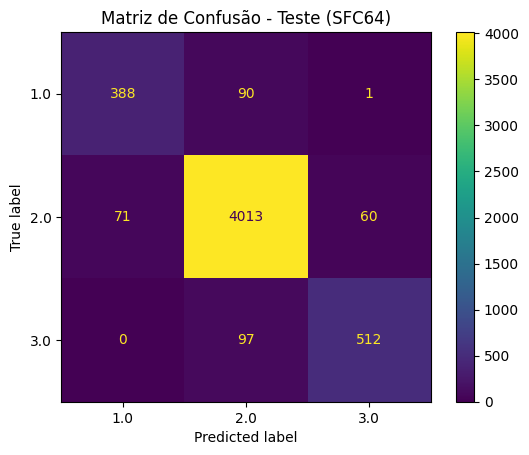

In [25]:
resultados["SFC64"] = run_experiment(
    generator_name="SFC64",
    random_state=gen2,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    cv=7,
    plot_val_confusion=True,
    plot_test_confusion=True,
)



===== Gerador: MT19937 =====
Validação cruzada (MT19937) - accuracy: 0.9325 ± 0.0040
Acurácia (Validação): 0.9404
              precision    recall  f1-score   support

         1.0       0.85      0.77      0.81       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.86      0.88       609

    accuracy                           0.94      5232
   macro avg       0.90      0.87      0.89      5232
weighted avg       0.94      0.94      0.94      5232



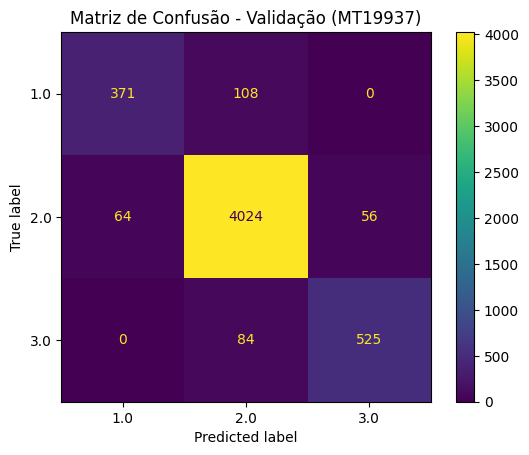

Acurácia (Teste): 0.9362
              precision    recall  f1-score   support

         1.0       0.84      0.79      0.82       479
         2.0       0.95      0.97      0.96      4144
         3.0       0.90      0.83      0.86       609

    accuracy                           0.94      5232
   macro avg       0.90      0.86      0.88      5232
weighted avg       0.94      0.94      0.94      5232



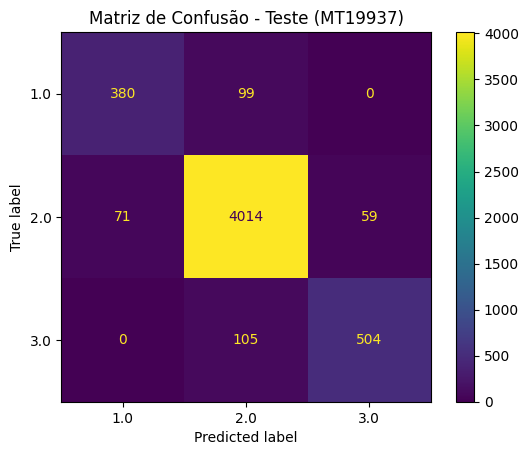

In [26]:
resultados["MT19937"] = run_experiment(
    generator_name="MT19937",
    random_state=gen3,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
    cv=7,
    plot_val_confusion=True,
    plot_test_confusion=True,
)


In [27]:
tabela_comparativa = combine_classification_results(resultados)
tabela_comparativa


,cv_accuracy_mean,cv_accuracy_std,val_accuracy,test_accuracy,classe_1.0_precision,classe_1.0_recall,classe_1.0_f1-score,classe_2.0_precision,classe_2.0_recall,classe_2.0_f1-score,classe_3.0_precision,classe_3.0_recall,classe_3.0_f1-score
gerador,,,,,,,,,,,,,
PCG64,0.932241,0.004528,0.939602,0.939602,0.852097,0.805846,0.828326,0.953985,0.970560,0.962201,0.902309,0.834154,0.866894
SFC64,0.933470,0.003569,0.938647,0.939029,0.845316,0.810021,0.827292,0.955476,0.968388,0.961889,0.893543,0.840722,0.866328
MT19937,0.932487,0.004008,0.940367,0.936162,0.842572,0.793319,0.817204,0.951636,0.968629,0.960057,0.895204,0.827586,0.860068
